In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
people = pd.read_csv('Master.csv')
batting = pd.read_csv('Batting.csv')

In [6]:
people.columns

Index(['playerID', 'birthYear', 'birthMonth', 'birthDay', 'birthCountry',
       'birthState', 'birthCity', 'deathYear', 'deathMonth', 'deathDay',
       'deathCountry', 'deathState', 'deathCity', 'nameFirst', 'nameLast',
       'nameGiven', 'weight', 'height', 'bats', 'throws', 'debut', 'finalGame',
       'retroID', 'bbrefID'],
      dtype='object')

In [8]:
people.head(3).transpose()

,0,1,2
playerID,aardsda01,aaronha01,aaronto01
birthYear,1981.0,1934.0,1939.0
birthMonth,12.0,2.0,8.0
birthDay,27.0,5.0,5.0
birthCountry,USA,USA,USA
birthState,CO,AL,AL
birthCity,Denver,Mobile,Mobile
deathYear,NaN,NaN,1984.0
deathMonth,NaN,NaN,8.0
deathDay,NaN,NaN,16.0


In [9]:
people = people[["playerID", "nameGiven", "bats", "throws", "debut"]]
people

,playerID,nameGiven,bats,throws,debut
0,aardsda01,David Allan,R,R,2004-04-06
1,aaronha01,Henry Louis,R,R,1954-04-13
2,aaronto01,Tommie Lee,R,R,1962-04-10
3,aasedo01,Donald William,R,R,1977-07-26
4,abadan01,Fausto Andres,L,L,2001-09-10
...,...,...,...,...,...
18841,zupofr01,Frank Joseph,L,R,1957-07-01
18842,zuvelpa01,Paul,R,R,1982-09-04
18843,zuverge01,George,R,R,1951-04-21
18844,zwilldu01,Edward Harrison,L,L,1910-08-14


In [10]:
people.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18846 entries, 0 to 18845
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   playerID   18846 non-null  object
 1   nameGiven  18807 non-null  object
 2   bats       17655 non-null  object
 3   throws     17868 non-null  object
 4   debut      18653 non-null  object
dtypes: object(5)
memory usage: 736.3+ KB


In [11]:
batting.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101332 entries, 0 to 101331
Data columns (total 22 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   playerID  101332 non-null  object 
 1   yearID    101332 non-null  int64  
 2   stint     101332 non-null  int64  
 3   teamID    101332 non-null  object 
 4   lgID      100595 non-null  object 
 5   G         101332 non-null  int64  
 6   AB        96183 non-null   float64
 7   R         96183 non-null   float64
 8   H         96183 non-null   float64
 9   2B        96183 non-null   float64
 10  3B        96183 non-null   float64
 11  HR        96183 non-null   float64
 12  RBI       95759 non-null   float64
 13  SB        94883 non-null   float64
 14  CS        72729 non-null   float64
 15  BB        96183 non-null   float64
 16  SO        88345 non-null   float64
 17  IBB       59620 non-null   float64
 18  HBP       93373 non-null   float64
 19  SH        89845 non-null   float64
 20  SF  

| 컬럼         | 의미                                      |
| ---------- | --------------------------------------- |
| `playerID` | 선수 고유 ID (문자열)                          |
| `yearID`   | 시즌 연도                                   |
| `stint`    | 해당 시즌 중 몇 번째 팀에서 뛰었는지 (1이면 하나의 팀에서만 활동) |
| `teamID`   | 소속 팀 약어 (예: NYA, BOS)                   |
| `lgID`     | 리그 (AL: 아메리칸 리그, NL: 내셔널 리그)            |
| `G`        | 경기 수                                    |
| `AB`       | At Bats: 타석 수 (희생번트, 볼넷 제외)             |
| `R`        | Runs: 득점 수                              |
| `H`        | Hits: 안타 수                              |
| `2B`       | 2루타 수                                   |
| `3B`       | 3루타 수                                   |
| `HR`       | 홈런 수                                    |
| `RBI`      | Runs Batted In: 타점                      |
| `SB`       | Stolen Bases: 도루                        |
| `CS`       | Caught Stealing: 도루 실패                  |
| `BB`       | Base on Balls: 볼넷                       |
| `SO`       | Strikeouts: 삼진                          |
| `IBB`      | Intentional Walks: 고의 사구                |
| `HBP`      | Hit By Pitch: 몸에 맞는 볼                   |
| `SH`       | Sacrifice Hits: 희생번트                    |
| `SF`       | Sacrifice Flies: 희생 플라이                 |
| `GIDP`     | Ground Into Double Play: 병살타            |


In [12]:
df = pd.merge(batting, people, on='playerID')
df = df[df['AB'] > 50]  # 최소 타석 필터링
df['AVG'] = df['H'] / df['AB']
df

,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,...,nameGiven,weight,height,bats,throws,debut,finalGame,retroID,bbrefID,AVG
1,addybo01,1871,1,RC1,NaN,25,118.0,30.0,32.0,6.0,...,Robert Edward,160.0,68.0,L,L,1871-05-06,1877-10-06,addyb101,addybo01,0.271186
2,allisar01,1871,1,CL1,NaN,29,137.0,28.0,40.0,4.0,...,Arthur Algernon,150.0,68.0,NaN,NaN,1871-05-04,1876-10-05,allia101,allisar01,0.291971
3,allisdo01,1871,1,WS3,NaN,27,133.0,28.0,44.0,10.0,...,Douglas L.,160.0,70.0,R,R,1871-05-05,1883-07-13,allid101,allisdo01,0.330827
4,ansonca01,1871,1,RC1,NaN,25,120.0,29.0,39.0,11.0,...,Adrian Constantine,227.0,72.0,R,R,1871-05-06,1897-10-03,ansoc101,ansonca01,0.325000
7,barnero01,1871,1,BS1,NaN,31,157.0,66.0,63.0,10.0,...,Charles Roscoe,145.0,68.0,R,R,1871-05-05,1881-09-21,barnr102,barnero01,0.401274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101325,zimmejo02,2015,1,WAS,NL,33,63.0,4.0,10.0,1.0,...,Jordan M.,225.0,74.0,R,R,2009-04-20,2015-09-30,zimmj003,zimmejo02,0.158730
101326,zimmery01,2015,1,WAS,NL,95,346.0,43.0,86.0,25.0,...,Ryan Wallace,220.0,75.0,R,R,2005-09-01,2015-09-07,zimmr001,zimmery01,0.248555
101328,zobribe01,2015,1,OAK,AL,67,235.0,39.0,63.0,20.0,...,Benjamin Thomas,210.0,75.0,B,R,2006-08-01,2015-10-04,zobrb001,zobribe01,0.268085
101329,zobribe01,2015,2,KCA,AL,59,232.0,37.0,66.0,16.0,...,Benjamin Thomas,210.0,75.0,B,R,2006-08-01,2015-10-04,zobrb001,zobribe01,0.284483


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50266 entries, 1 to 101330
Data columns (total 46 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   playerID      50266 non-null  object 
 1   yearID        50266 non-null  int64  
 2   stint         50266 non-null  int64  
 3   teamID        50266 non-null  object 
 4   lgID          49790 non-null  object 
 5   G             50266 non-null  int64  
 6   AB            50266 non-null  float64
 7   R             50266 non-null  float64
 8   H             50266 non-null  float64
 9   2B            50266 non-null  float64
 10  3B            50266 non-null  float64
 11  HR            50266 non-null  float64
 12  RBI           50070 non-null  float64
 13  SB            49357 non-null  float64
 14  CS            36166 non-null  float64
 15  BB            50266 non-null  float64
 16  SO            45344 non-null  float64
 17  IBB           28591 non-null  float64
 18  HBP           48438 non-null  

In [17]:
fielding = pd.read_csv("Fielding.csv")
df = pd.merge(df, fielding[['playerID', 'yearID', 'POS']], on=[
              'playerID', 'yearID'])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441026 entries, 0 to 441025
Data columns (total 48 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   playerID      441026 non-null  object 
 1   yearID        441026 non-null  int64  
 2   stint         441026 non-null  int64  
 3   teamID        441026 non-null  object 
 4   lgID          437074 non-null  object 
 5   G             441026 non-null  int64  
 6   AB            441026 non-null  float64
 7   R             441026 non-null  float64
 8   H             441026 non-null  float64
 9   2B            441026 non-null  float64
 10  3B            441026 non-null  float64
 11  HR            441026 non-null  float64
 12  RBI           437886 non-null  float64
 13  SB            434500 non-null  float64
 14  CS            370212 non-null  float64
 15  BB            441026 non-null  float64
 16  SO            410639 non-null  float64
 17  IBB           343713 non-null  float64
 18  HBP 

<Axes: xlabel='POS_x', ylabel='AVG'>

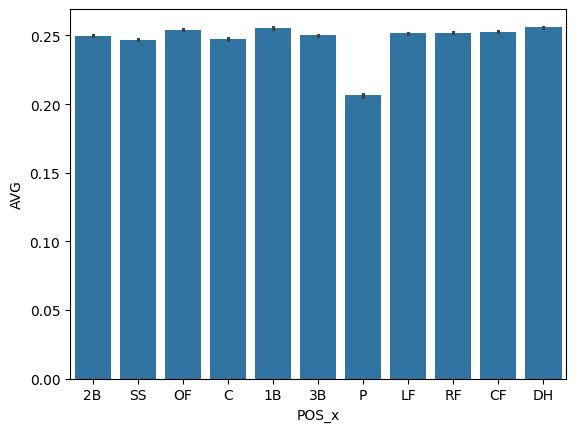

In [19]:
sns.barplot(x='POS_x', y='AVG', data=df)